In [95]:
#General Research Question: Did the 1965 Immigration and Nationality Act play a large roll in increasing racial diversity in the United States?
#Specific Research Question: How did the percentage of the Asian and White population change before and after the 1965 Immigration Act?
#The first part of the process includes gathering US population census data from each decade surrounding the act from the IPUMS NGHIS website.
#This actually took me quite a while because it was very difficult to load the data from the IPUMS NHGIS database
#I also realized you would not have access
#to the files to run the code yourself in a different session without me putting the data first in a github repo.
# Here I just cloned the data
!git clone https://github.com/CLBStyle/Milestone-3-Minimum-Viable-Product.git
%cd 1965-immigration-data

Cloning into 'Milestone-3-Minimum-Viable-Product'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 36 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 14.27 KiB | 14.27 MiB/s, done.
Resolving deltas: 100% (8/8), done.
[Errno 2] No such file or directory: '1965-immigration-data'
/content/1965-immigration-data/1965-immigration-data/1965-immigration-data/1965-immigration-data/1965-immigration-data


In [96]:
# A quick double check to make sure the data is there
!ls data

nhgis0001_ds104_1980_nation_codebook.txt
nhgis0001_ds104_1980_nation.csv
nhgis0001_ds120_1990_nation_codebook.txt
nhgis0001_ds120_1990_nation.csv
nhgis0001_ds83_1950_nation_codebook.txt
nhgis0001_ds83_1950_nation.csv
nhgis0001_ds91_1960_nation_codebook.txt
nhgis0001_ds91_1960_nation.csv
nhgis0001_ds95_1970_nation_codebook.txt
nhgis0001_ds95_1970_nation.csv
README.md


In [97]:
import pandas as pd
import matplotlib.pyplot as plt

In [98]:
# pandas reading each decades racial population report
df_1950 = pd.read_csv("data/nhgis0001_ds83_1950_nation.csv")
df_1960 = pd.read_csv("data/nhgis0001_ds91_1960_nation.csv")
df_1970 = pd.read_csv("data/nhgis0001_ds95_1970_nation.csv")
df_1980 = pd.read_csv("data/nhgis0001_ds104_1980_nation.csv")
df_1990 = pd.read_csv("data/nhgis0001_ds120_1990_nation.csv")

In [99]:
# I wanted to further check that the data was there and that pandas was actually reading it. The colums look horrendous
# and are indescernible. However, you are able to read it thanks to a codebook that you can also download (also in my repository)
# that specifies what each axis title stands for.
# The B5S columns all refer to the specific races/ethnicities that the census counted at the time.
# Note that 1950 is not included yet because I could not find a table that counted the Asian population; I could only find a "White and
# Non-White" table.
print("1960 columns:")
print(df_1960.columns.tolist())

print("\n1970 columns:")
print(df_1970.columns.tolist())

print("\n1980 columns:")
print(df_1980.columns.tolist())

print("\n1990 columns:")
print(df_1990.columns.tolist())

1960 columns:
['GISJOIN', 'YEAR', 'NATION', 'NATIONA', 'AREANAME', 'STATEICP', 'COUNTYICP', 'B5S001', 'B5S002', 'B5S003', 'B5S004', 'B5S005', 'B5S006', 'B5S007', 'B5S008', 'B5S009', 'B5S010', 'B5S011', 'B5S012', 'B5S013', 'B5S014']

1970 columns:
['GISJOIN', 'YEAR', 'NATION', 'NATIONA', 'AREANAME', 'CENCNTY', 'CBD', 'SEA', 'CEB001', 'CEB002', 'CEB003', 'CEB004', 'CEB005', 'CEB006', 'CEB007', 'CEB008', 'CEB009', 'CEB010', 'CEB011', 'CEB012', 'CEB013', 'CEB014', 'CEB015', 'CEB016', 'CEB017', 'CEB018']

1980 columns:
['GISJOIN', 'YEAR', 'NATION', 'NATIONA', 'FSTATUS', 'MCDSEQNO', 'SEA', 'UATYPE', 'PLACDESC', 'CBD', 'INDSUBR', 'LONGITUD', 'LATITUDE', 'LANDAREA', 'AREANAME', 'SUPFLG01', 'SUPFLG02', 'SUPFLG03', 'SUPFLG04', 'SUPFLG05', 'SUPFLG06', 'SUPFLG07', 'SUPFLG08', 'SUPFLG09', 'SUPFLG10', 'SUPFLG11', 'SUPFLG12', 'SUPFLG13', 'SUPFLG14', 'SUPFLG15', 'SUPFLG16', 'SUPFLG17', 'SUPFLG18', 'SUPFLG19', 'SUPFLG20', 'SUPFLG21', 'C9D001', 'C9D002', 'C9D003', 'C9D004', 'C9D005', 'C9D006', 'C9D007',

In [100]:
# For 1960, the census only recorded specific Asian ethnicities not an overall "Asian" race that would likely be recorded today.
# Additionally there were an extremely limited number of ethnicities that the census recorded as shown below which definitely left out people.
# I just used a simple sum function to add the ethnicities together that would
# be considered "Asian" today. There was no "race" table offered in the NHGIS, but rather only sex by race tables in the 1960s. I had to sum
# both of them together.
# Another funny aside, the census had a chart for "Indian" that I almost included until I realized that that could have been referring to Native
# Americans, considering the time period. Sure enough, upon asking ChatGPT, it turns out the US government referred to Native Americans
# under the umbrella term of "Indian" in their census back in the 1960s.
asian_1960 = (
    df_1960["B5S004"].iloc[0] +  # Male Japanese
    df_1960["B5S005"].iloc[0] +  # Male Chinese
    df_1960["B5S006"].iloc[0] +  # Male Filipino
    df_1960["B5S011"].iloc[0] +  # Female Japanese
    df_1960["B5S012"].iloc[0] +  # Female Chinese
    df_1960["B5S013"].iloc[0]    # Female Filipino
    )

In [101]:
# At this point I realized that in the modern census, Asian and Pacific Islander are counted together, so I added these ethnicities to the total.
# As you can see, there are more categories but still many Asian ethnicities missing out.
asian_1970 = (
    df_1970["CEB004"].iloc[0] +  # Male Japanese
    df_1970["CEB005"].iloc[0] +  # Male Chinese
    df_1970["CEB006"].iloc[0] +  # Male Filipino
    df_1970["CEB007"].iloc[0] +  # Male Hawaiian
    df_1970["CEB008"].iloc[0] +  # Male Korean
    df_1970["CEB013"].iloc[0] +  # Female Japanese
    df_1970["CEB014"].iloc[0] +  # Female Chinese
    df_1970["CEB015"].iloc[0] +  # Female Filipino
    df_1970["CEB016"].iloc[0] +  # Female Hawaiian
    df_1970["CEB017"].iloc[0]    # Female Korean
)

In [102]:
# There was finally a race category that included "Asian Indians" and additionally a table that added up males and females.
asian_1980 = (
    df_1980["C9D006"].iloc[0] +  # Japanese
    df_1980["C9D007"].iloc[0] +  # Chinese
    df_1980["C9D008"].iloc[0] +  # Filipino
    df_1980["C9D009"].iloc[0] +  # Korean
    df_1980["C9D010"].iloc[0] +  # Asian Indian
    df_1980["C9D011"].iloc[0] +  # Vietnamese
    df_1980["C9D012"].iloc[0] +  # Hawaiian
    df_1980["C9D013"].iloc[0] +  # Guamanian
    df_1980["C9D014"].iloc[0]    # Samoan
)

In [103]:
# In 1990, they finally added a sum of Asian and Pacific Islander people's into one census.
asian_1990 = df_1990["EUY004"].iloc[0]

In [104]:
# Using the sum function was very annoying and tedious, I thought it might be easier to use a dictionary from this point, considering
# that adding up the total populatios to calculate percentages would take even longer. This puts the Asians total in a dictionary.
asian_by_year = {
    1960: asian_1960,
    1970: asian_1970,
    1980: asian_1980,
    1990: asian_1990
    }

In [105]:
# Put dataframes into a dictionary
data_by_year = {
    1960: df_1960,
    1970: df_1970,
    1980: df_1980,
    1990: df_1990
}

In [106]:
# Dictionary of all race columns used to calculate total population
total_columns = {
    1960: ["B5S001", "B5S002", "B5S003", "B5S004", "B5S005", "B5S006", "B5S007",
           "B5S008", "B5S009", "B5S010", "B5S011", "B5S012", "B5S013", "B5S014"],
    1970: ["CEB001", "CEB002", "CEB003", "CEB004", "CEB005", "CEB006", "CEB007",
           "CEB008", "CEB009", "CEB010", "CEB011", "CEB012", "CEB013", "CEB014",
           "CEB015", "CEB016", "CEB017", "CEB018"],
    1980: ["C9D001", "C9D002", "C9D003", "C9D004", "C9D005", "C9D006", "C9D007",
           "C9D008", "C9D009", "C9D010", "C9D011", "C9D012", "C9D013", "C9D014",
           "C9D015"],
    1990: ["EUY001", "EUY002", "EUY003", "EUY004", "EUY005"]
}

In [107]:
# Adds all of the columns together into the data frame
def sum_columns(df, column_list):
    return df[column_list].iloc[0].sum()

In [108]:
# Use loop to calculate totals and percentages
results = []

for year in data_by_year:
    df = data_by_year[year]
    total_population = sum_columns(df, total_columns[year])
    asian_population = asian_by_year[year]
    asian_percent = (asian_population / total_population) * 100

    results.append({
        "year": year,
        "asian_population": asian_population,
        "total_population": total_population,
        "asian_percent": asian_percent
    })

In [109]:
# I made the data table first and displayed it like this. I looked at the numbers and it is very accurate.
summary = pd.DataFrame(results)
summary = summary.sort_values("year")
summary["asian_percent"] = summary["asian_percent"].round(3)
summary

,year,asian_population,total_population,asian_percent
0,1960,877934,179323180,0.490
1,1970,1573099,203211926,0.774
2,1980,3500439,226545805,1.545
3,1990,7273662,248709873,2.925


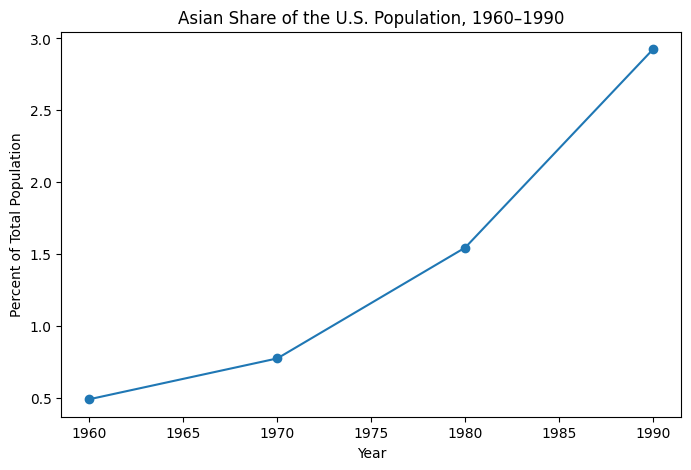

In [110]:
# Using MatPlot to show the change in population. Lines create a curve like function, indicating an exponential increase
# in the Asian population as a percentage of the total from 1960-90.
plt.figure(figsize=(8,5))
plt.plot(summary["year"], summary["asian_percent"], marker="o")
plt.title("Asian Share of the U.S. Population, 1960–1990")
plt.xlabel("Year")
plt.ylabel("Percent of Total Population")
plt.show()

In [88]:
# At this point I was further interested in not only seeing if I could find an Asian Population increase as a result of immigration
# but also a White population decrease as a result of the 1965 Immigration Act. Since, now I only had to calculate White percentages
# I was able to go further back in time where I found a "White and Non-White" census. The first task here is to update the
# data table to include 1950.
data_by_year = {
    1950: df_1950,
    1960: df_1960,
    1970: df_1970,
    1980: df_1980,
    1990: df_1990
}

In [111]:
white_by_year = {
    1950: df_1950["B1T001"].iloc[0],
    1960: df_1960["B5S001"].iloc[0] + df_1960["B5S008"].iloc[0],
    1970: df_1970["CEB001"].iloc[0] + df_1970["CEB010"].iloc[0],
    1980: df_1980["C9D001"].iloc[0],
    1990: df_1990["EUY001"].iloc[0] }

In [112]:
# I remade the dictionary to include 1950. I could have just updated the dictionary above but I wanted to show my process and logic updates
# without it seeming confusing.
total_columns = {
    1950: ["B1T001", "B1T002"],
    1960: ["B5S001", "B5S002", "B5S003", "B5S004", "B5S005", "B5S006", "B5S007",
           "B5S008", "B5S009", "B5S010", "B5S011", "B5S012", "B5S013", "B5S014"],
    1970: ["CEB001", "CEB002", "CEB003", "CEB004", "CEB005", "CEB006", "CEB007",
           "CEB008", "CEB009", "CEB010", "CEB011", "CEB012", "CEB013", "CEB014",
           "CEB015", "CEB016", "CEB017", "CEB018"],
    1980: ["C9D001", "C9D002", "C9D003", "C9D004", "C9D005", "C9D006", "C9D007",
           "C9D008", "C9D009", "C9D010", "C9D011", "C9D012", "C9D013", "C9D014",
           "C9D015"],
    1990: ["EUY001", "EUY002", "EUY003", "EUY004", "EUY005"]
}

In [113]:
# This is also not neccessary to remake, but this is for just in case the one above reset.
def sum_columns(df, column_list):
    return df[column_list].iloc[0].sum()

In [114]:
# Same loop process to calculate White percentage.
white_results = []

for year in data_by_year:
    df = data_by_year[year]
    total_population = sum_columns(df, total_columns[year])
    white_population = white_by_year[year]
    white_percent = (white_population / total_population) * 100

    white_results.append({
        "year": year,
        "white_population": white_population,
        "total_population": total_population,
        "white_percent": white_percent
    })

In [115]:
# Summary is once again very accurate according to the census data.
white_summary = pd.DataFrame(white_results)
white_summary = white_summary.sort_values("year")
white_summary["white_percent"] = white_summary["white_percent"].round(3)

white_summary

,year,white_population,total_population,white_percent
0,1960,158831736,179323180,88.573
1,1970,177748975,203211926,87.470
2,1980,188371622,226545805,83.149
3,1990,199686070,248709873,80.289


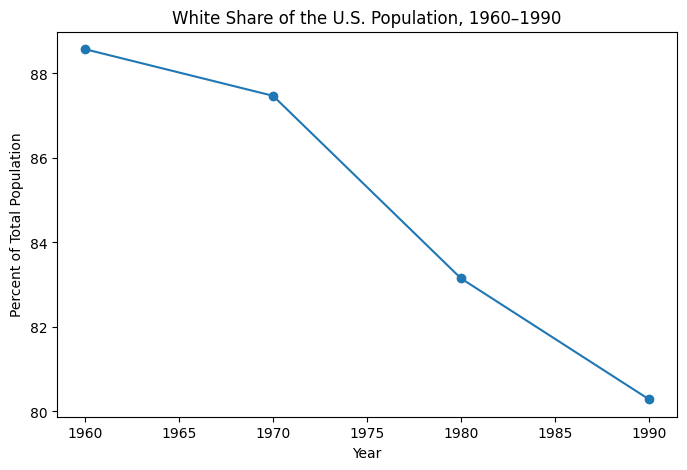

In [116]:
# I wanted to include 1950 to confirm my thesis. 1950 to 1960 is a control decade; I wanted to make sure the White population wasn't
# drastically changing before the Immigration Act (even though it did decrease).
# The data supports the thesis showing how how the decrease was slow at first and then rapidly accelerates in the 1970s,
# pretty in line with the 1965 Immigration Act. However, the curve levels off a bit from the 80s to the 90s.
plt.figure(figsize=(8,5))
plt.plot(white_summary["year"], white_summary["white_percent"], marker="o")
plt.title("White Share of the U.S. Population, 1960–1990")
plt.xlabel("Year")
plt.ylabel("Percent of Total Population")
plt.show()